# Case study: sc-SVC analysis of fine-grained T-cell states in Xenium data

## Notebook Guide

**Purpose.** Preserve and explain the sc-SVC analysis workflow for the Xenium T-cell dataset.

**Inputs.** Use either the real-world ST raw data required for reconstruction or the released T-cell `spatial.h5ad` / `expr.h5ad` pair described below.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the [Real-world ST datasets](https://zenodo.org/records/21921802), place `P2CRC_Xenium.h5ad` and `adata_sc_all_reanno.h5ad` under `../../raw_data/Real_application/`, and run `python reconstruct.py --config configs/application/Xenium.yaml --select-ct T` from the repository root.
2. **Start from released results.** Download the [REVISE-reconstructed sc-SVC Xenium data](https://zenodo.org/records/18389211) and place the T-cell pair at `../../results/sc_SVC_case/P2CRC_Xenium/T/spatial.h5ad` and `../../results/sc_SVC_case/P2CRC_Xenium/T/expr.h5ad`. Then begin with **Load Reconstructed SVCs** below.

**Reconstruction input.** The route starts from `../../raw_data/Real_application/P2CRC_Xenium.h5ad` and `../../raw_data/Real_application/adata_sc_all_reanno.h5ad`. The spatial object provides counts and `obsm["spatial"]`; the reference provides shared genes, broad `Level1` labels, and `Level2` subtypes.

**Reconstruction command.** `python reconstruct.py --config configs/application/Xenium.yaml --select-ct T`

**Expected reconstructed outputs and analysis inputs.** `../../results/sc_SVC_case/P2CRC_Xenium/T/spatial.h5ad` is the spatial-side SVC object, retaining spatial identities in the Xenium panel gene space. `../../results/sc_SVC_case/P2CRC_Xenium/T/expr.h5ad` is the expression-side reference-cell object assigned the same SVC phenotype semantics in a larger gene space. They are **not observation-paired** matrices and must not be interpreted as before/after measurements of the same cells.

**Analysis workflow.** Load the two objects; inspect subtype maps; review all reconstructed clusters before selecting focal follow-up through marker and spatial evidence; then compare selected programs against the normal-infiltrated comparator on the spatial-side and expression-side objects.

**Outputs.** Subtype maps and phenotype-specific DEG, volcano, and enrichment artifacts are stored under `../../output/P2CRC_Xenium/T/`.

**Execution and evidence boundary.** The displayed outputs are accepted execution snapshots. This path-contract update does not establish biological validity or reconstruction parity.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")
import warnings
warnings.filterwarnings("ignore")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

data_root = "../../results/sc_SVC_case/P2CRC_Xenium"
case_dir = f"{data_root}/T"
analysis_output_dir = os.environ.get("REVISE_ANALYSIS_OUTPUT_ROOT", "../../output/P2CRC_Xenium/T")
output_dir = analysis_output_dir
os.makedirs(f"{output_dir}/sc_SVC", exist_ok=True)
select_ct = "T"


Matplotlib is building the font cache; this may take a moment.


## Load the reconstructed T-cell objects

**Question.** Do the released spatial-side and expression-side objects carry the expected SVC clusters and reference annotations?

**Method.** The notebook loads both H5AD files and initializes the legacy `ScSVCAnalysis` facade used by the published analysis. The following confusion table summarizes how expression-side `SVC_cluster` labels relate to `Level2` reference labels; it is an annotation check rather than a performance metric.


In [2]:
import os
import scanpy as sc

import sys
sys.path.append("../../")
from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
import revise.analysis.bio as _revise_bio
from revise.analysis.advanced.enrichment import get_enrichment_local as _strict_get_enrichment_local

_revise_bio.get_enrichment = _strict_get_enrichment_local


sc_svc_expr = sc.read_h5ad(f"{case_dir}/expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{case_dir}/spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr, 
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Conducting differential expression analysis...


In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

Level2,CD4T,CD8T,NK,Tprolif
SVC_cluster,,,,
0,553,6,0,57
1,22,3,0,262
2,164,1098,99,73
3,498,85,1,7
4,712,50,0,32
5,819,7,0,31
6,197,99,53,36


In [4]:
# cm_df.div(cm_df.sum(axis=1), axis=0)
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)

styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)

styled

Level2,CD4T,CD8T,NK,Tprolif
SVC_cluster,,,,
0,89.77%,0.97%,0.00%,9.25%
1,7.67%,1.05%,0.00%,91.29%
2,11.44%,76.57%,6.90%,5.09%
3,84.26%,14.38%,0.17%,1.18%
4,89.67%,6.30%,0.00%,4.03%
5,95.57%,0.82%,0.00%,3.62%
6,51.17%,25.71%,13.77%,9.35%


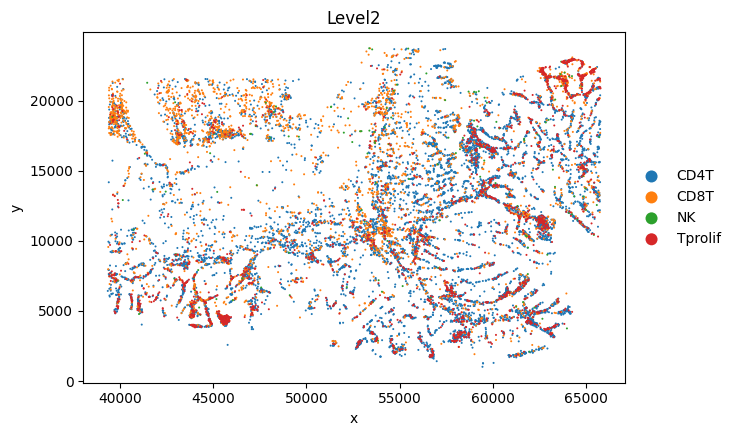

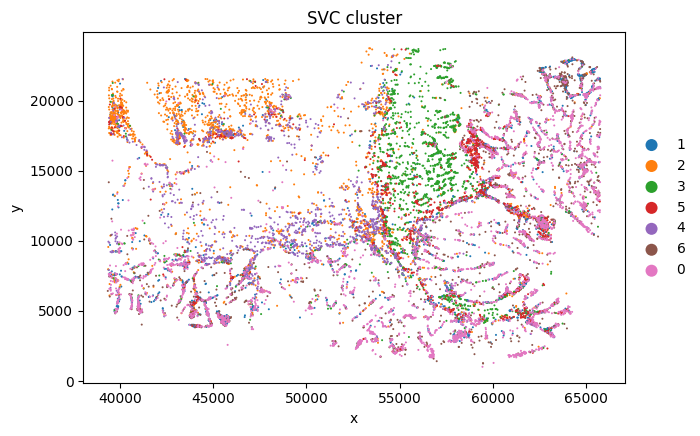

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['1', '2', '3', '5', '4', '6', '0']  # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Where are the reconstructed T-cell states located?

**Method and figure reading.** The maps use the spatial-side object. Coordinates show the Xenium cell locations; colors show either expert `Level2` labels or sc-SVC clusters. The separate and side-by-side views are both retained so readers can inspect subtype organization and its relationship to the original annotation.

**Direct observation.** The current output resolves several spatially organized T-cell clusters within the analyzed tissue. The maps describe distribution; they do not by themselves validate phenotype identity or mechanism.

**Interpretation boundary.** Phenotype and tissue-context interpretations are made only after the integrated all-cluster marker and spatial review below; the global map itself does not select focal exemplars or validate mechanisms.


<Figure size 1000x800 with 0 Axes>

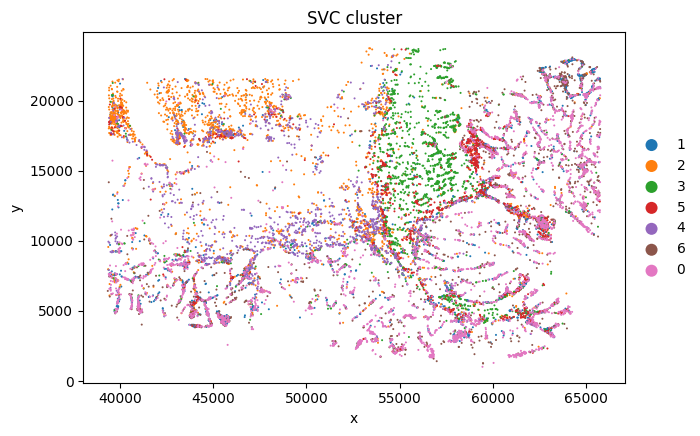

<Figure size 1000x1600 with 0 Axes>

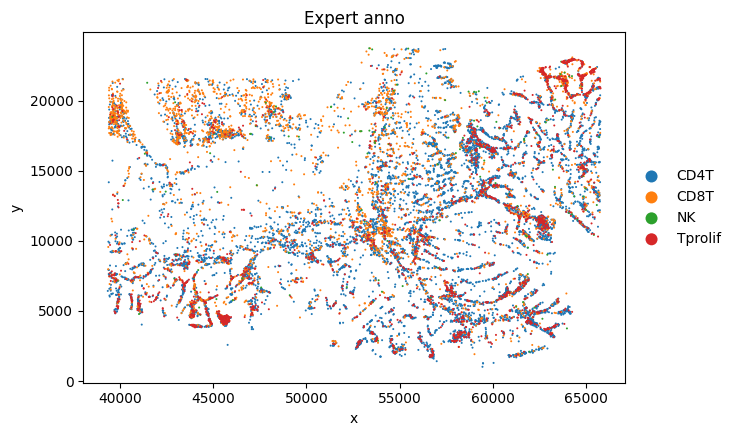

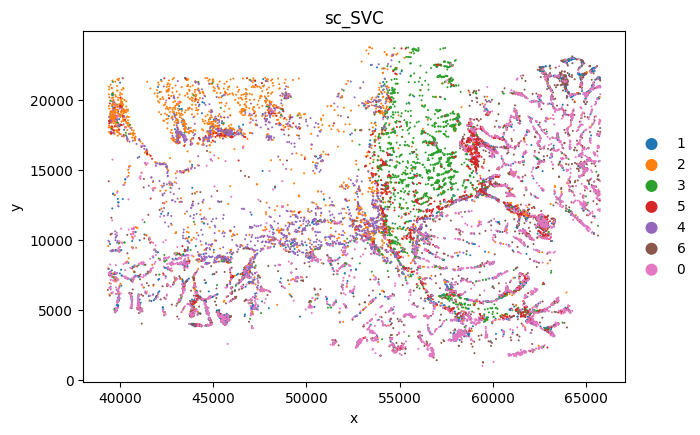

In [6]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## Evidence collection across all reconstructed T-cell clusters

**Question.** Before selecting focal exemplars, what marker and spatial evidence is present across all seven reconstructed clusters?

**Analysis sequence.** Marker identities are annotated immediately after the dot plot, then all seven clusters are visualized spatially before the integrated summary and focal selection. The spatial-side and expression-side H5AD objects share phenotype semantics but contain different, non-observation-paired cells.


In [7]:
all_cluster_nums = [str(i) for i in range(7)]
spatial_cluster = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].astype(str)
spatial_counts = spatial_cluster.value_counts().reindex(all_cluster_nums, fill_value=0)


### Marker evidence across all clusters

**Method.** The curated panel is plotted for every expression-side cluster before any focal selection. No markers are recalculated after restricting to a focal trio.

**How to read the figure.** Dot size and color summarize expression among expression-side cells assigned to each cluster. The plot retains neutral Cluster 0–Cluster 6 labels; the marker-informed identity annotations follow immediately below.


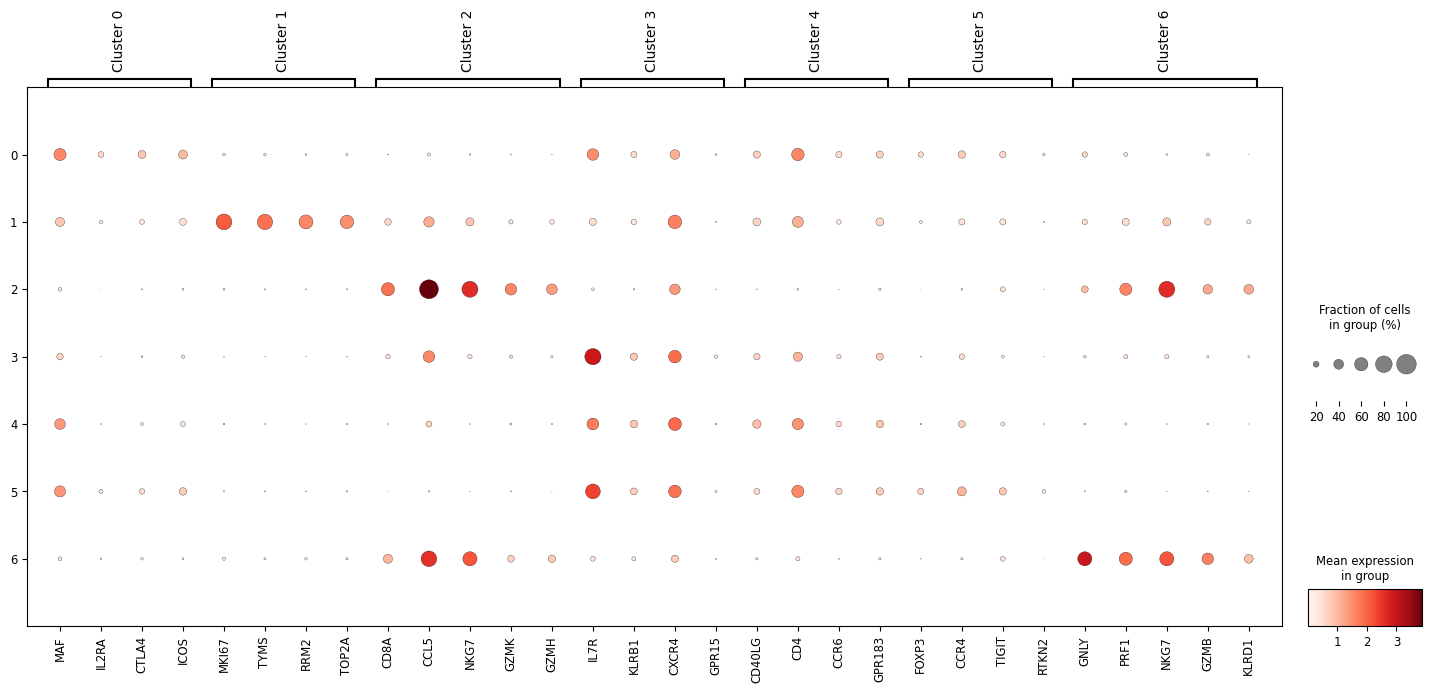

In [8]:
import matplotlib.pyplot as plt

all_cluster_marker_panels = {
    'Cluster 0': ['MAF', 'IL2RA', 'CTLA4', 'ICOS'],
    'Cluster 1': ['MKI67', 'TYMS', 'RRM2', 'TOP2A'],
    'Cluster 2': ['CD8A', 'CCL5', 'NKG7', 'GZMK', 'GZMH'],
    'Cluster 3': ['IL7R', 'KLRB1', 'CXCR4', 'GPR15'],
    'Cluster 4': ['CD40LG', 'CD4', 'CCR6', 'GPR183'],
    'Cluster 5': ['FOXP3', 'CCR4', 'TIGIT', 'RTKN2'],
    'Cluster 6': ['GNLY', 'PRF1', 'NKG7', 'GZMB', 'KLRD1'],
}
marker_adata = sc_svc_analysis.sc_SVC_adata_expr[
    sc_svc_analysis.sc_SVC_adata_expr.obs['SVC_cluster'].astype(str).isin(all_cluster_nums)
].copy()
marker_adata.obs['SVC_cluster'] = pd.Categorical(
    marker_adata.obs['SVC_cluster'].astype(str),
    categories=all_cluster_nums,
    ordered=True,
)
sc.pp.normalize_total(marker_adata, target_sum=1e4)
sc.pp.log1p(marker_adata)
marker_dotplot = sc.pl.dotplot(
    marker_adata,
    all_cluster_marker_panels,
    groupby='SVC_cluster',
    categories_order=all_cluster_nums,
    dendrogram=False,
    figsize=(18, 7),
    show=False,
    return_fig=True,
)
marker_dotplot.show()
plt.close('all')


## Marker-informed identity annotations

The displayed marker programs support the conservative functional/state annotations below. They are descriptions of reconstructed marker programs, not independent lineage validation or a cluster-quality ranking.

The all-cluster Hallmark screen is not carried forward because its significant terms are uneven across clusters and do not improve the identity interpretation beyond the dot plot. The focal pathway analysis remains below, after focal selection.


In [9]:
all_cluster_annotations = pd.DataFrame(
    {
        'Cluster': all_cluster_nums,
        'Functional/state annotation': [
            'activated/regulatory CD4-like',
            'cycling/proliferative T',
            'cytotoxic CD8-like',
            'IL7R+ memory/TRM-like',
            'CD40LG+ helper CD4-like',
            'FOXP3+ regulatory T',
            'cytotoxic/NK-like mixed',
        ],
        'Representative markers': [
            ', '.join(all_cluster_marker_panels[f'Cluster {cluster}'])
            for cluster in all_cluster_nums
        ],
    }
)
all_cluster_annotations.set_index('Cluster')


,Functional/state annotation,Representative markers
Cluster,,
0,activated/regulatory CD4-like,"MAF, IL2RA, CTLA4, ICOS"
1,cycling/proliferative T,"MKI67, TYMS, RRM2, TOP2A"
2,cytotoxic CD8-like,"CD8A, CCL5, NKG7, GZMK, GZMH"
3,IL7R+ memory/TRM-like,"IL7R, KLRB1, CXCR4, GPR15"
4,CD40LG+ helper CD4-like,"CD40LG, CD4, CCR6, GPR183"
5,FOXP3+ regulatory T,"FOXP3, CCR4, TIGIT, RTKN2"
6,cytotoxic/NK-like mixed,"GNLY, PRF1, NKG7, GZMB, KLRD1"


### Spatial localization across all clusters

**Method and figure reading.** Each panel highlights one spatial-side cluster while all other T cells remain gray. All panels share the same coordinates, limits, and aspect ratio, so this is a qualitative comparison of localization rather than a region-enrichment statistic. The current H5AD inputs contain no tumor/normal/interface ROI polygons.

**Direct observation.** The small multiples provide the spatial evidence for every cluster before any focal exemplars are chosen.


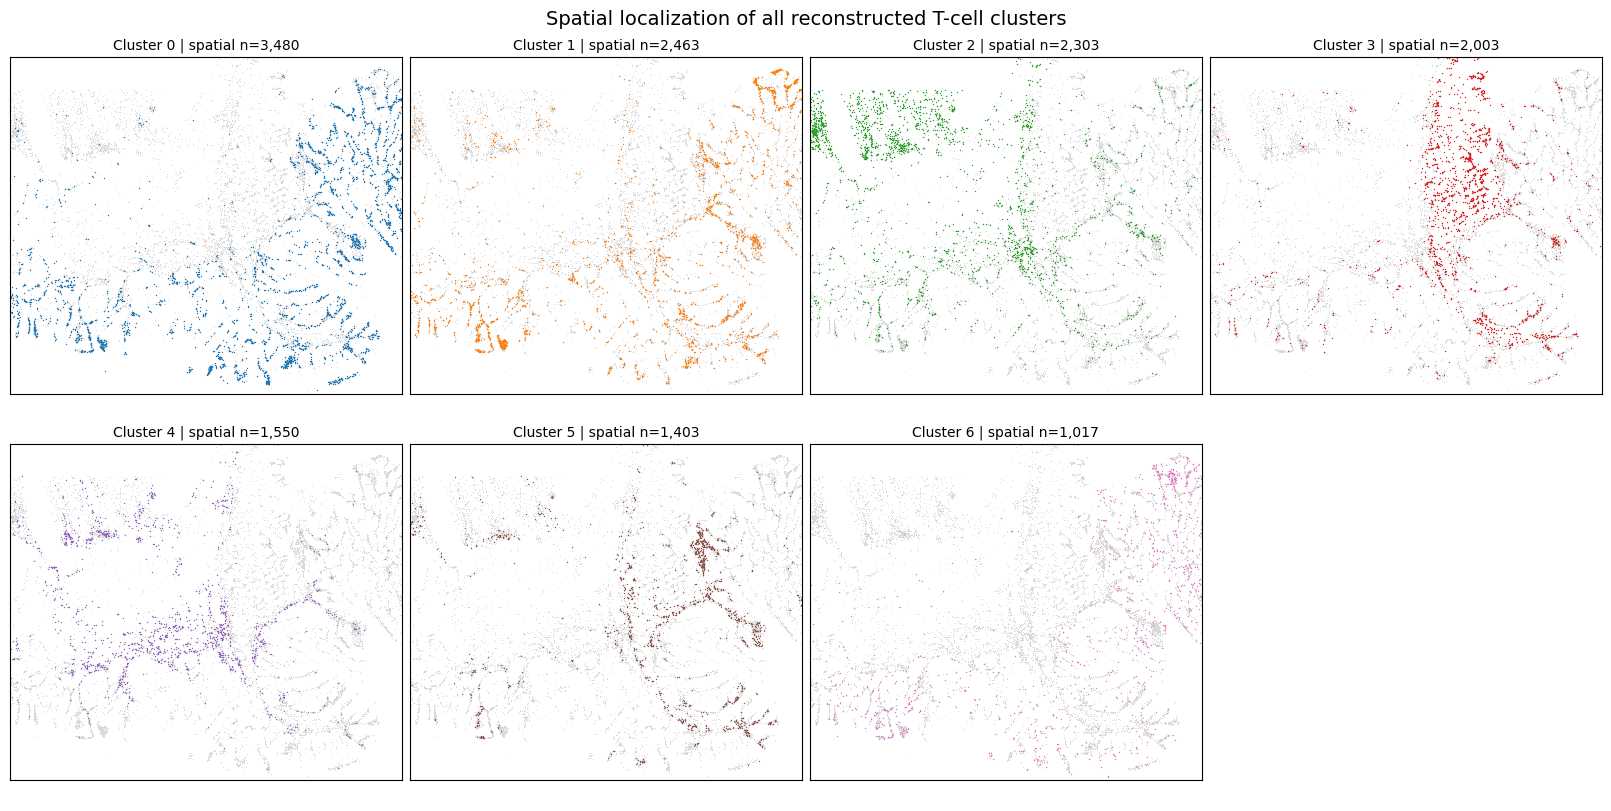

In [10]:
spatial_adata = sc_svc_analysis.sc_SVC_adata_spatial
spatial_x = spatial_adata.obs['x'].to_numpy()
spatial_y = spatial_adata.obs['y'].to_numpy()
spatial_cluster_labels = spatial_adata.obs['SVC_cluster'].astype(str).to_numpy()
spatial_xlim = (spatial_x.min(), spatial_x.max())
spatial_ylim = (spatial_y.min(), spatial_y.max())
cluster_colors = {
    cluster: plt.cm.tab10(index)
    for index, cluster in enumerate(all_cluster_nums)
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for ax, cluster in zip(axes.flat, all_cluster_nums):
    target = spatial_cluster_labels == cluster
    ax.scatter(spatial_x, spatial_y, s=0.45, c='#d9d9d9', linewidths=0, rasterized=True)
    ax.scatter(
        spatial_x[target],
        spatial_y[target],
        s=1.0,
        c=cluster_colors[cluster],
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(f"Cluster {cluster} | spatial n={spatial_counts.loc[cluster]:,}", fontsize=10)
    ax.set_xlim(spatial_xlim)
    ax.set_ylim(spatial_ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])

axes.flat[-1].set_axis_off()
fig.suptitle('Spatial localization of all reconstructed T-cell clusters', fontsize=14)
plt.show()
plt.close(fig)


## Integrated all-cluster summary and focal selection

**Integrated interpretation.** The table below combines the marker-informed annotations with the spatial review after every cluster has been examined. It retains only the evidence needed to interpret the clusters and explain the focal selection.

**Spatial-context labels.** An em dash indicates that no paper-defined tumor-core, normal-core, or interface label is assigned here. It does not indicate lower quality, absent localization, or absent marker interpretability.


In [11]:
spatial_contexts = {
    '0': '—',
    '1': 'Tumor core',
    '2': '—',
    '3': 'Normal core',
    '4': '—',
    '5': 'Tumor–normal leading edge/interface',
    '6': '—',
}
all_cluster_summary = all_cluster_annotations.assign(
    **{'Spatial context': all_cluster_annotations['Cluster'].map(spatial_contexts)}
)
all_cluster_summary


,Cluster,Functional/state annotation,Representative markers,Spatial context
0,0,activated/regulatory CD4-like,"MAF, IL2RA, CTLA4, ICOS",—
1,1,cycling/proliferative T,"MKI67, TYMS, RRM2, TOP2A",Tumor core
2,2,cytotoxic CD8-like,"CD8A, CCL5, NKG7, GZMK, GZMH",—
3,3,IL7R+ memory/TRM-like,"IL7R, KLRB1, CXCR4, GPR15",Normal core
4,4,CD40LG+ helper CD4-like,"CD40LG, CD4, CCR6, GPR183",—
5,5,FOXP3+ regulatory T,"FOXP3, CCR4, TIGIT, RTKN2",Tumor–normal leading edge/interface
6,6,cytotoxic/NK-like mixed,"GNLY, PRF1, NKG7, GZMB, KLRD1",—


### Why clusters 1, 3, and 5 are focal exemplars

The choice is made after the full seven-cluster review, with non-redundant spatial-context coverage as the primary criterion. The evidence is summarized below rather than converted into a composite quality score.

| Focal cluster | Integrated cellular/state evidence | Representative spatial context | Follow-up role |
| --- | --- | --- | --- |
| 1 | cycling/proliferative marker program: MKI67, TYMS, RRM2, TOP2A | Tumor core | Proliferation / paper T_0 |
| 3 | IL7R+ memory/TRM-like marker program: IL7R, KLRB1, CXCR4, GPR15 | Normal core | Normal-infiltrated comparator / paper T_2 TRM-like |
| 5 | FOXP3+ regulatory marker program: FOXP3, CCR4, TIGIT, RTKN2 | Tumor–normal leading edge/interface | Regulation / paper T_3 |

**Scope of the follow-up.** The three focal clusters were not selected by cluster size, assignment posterior, DEG yield, or apparent interpretability. The remaining four clusters received the same marker and spatial review; not being focal does not mean they are lower quality or unidentifiable. The deeper analyses below answer representative spatial-context questions and do not constitute a cluster-quality filter.


In [12]:
# Defined only after the integrated seven-cluster evidence synthesis above.
focal_cluster_nums = ['1', '3', '5']


## Focal follow-up: local pathway enrichment for the selected spatial exemplars

**Question.** After selecting the three spatial exemplars above, which pathway terms summarize the reconstructed Proliferation, normal-core comparator, and Regulation clusters before their focal marker comparison?

**Method.** ScSVCAnalysis.get_pathway_conclusion derives cluster DEGs and runs frozen local GSEApy enrichment against the bundled Hallmark GMT. The gene-set file, fold-change threshold, top-gene limit, and returned terms are part of the displayed execution snapshot.

**Direct observation.** The table reports terms returned for the current local resource and inputs. A missing term means it was not returned by this run; it is not evidence of absent pathway activity.

**Paper context.** The paper uses these functional programs together with curated markers to describe proliferative, TRM-like, and regulatory T-cell states. The frozen local enrichment supports executable reproduction but is not asserted to be identical to the historical online database version.


In [13]:
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["./pathway/h.all.v2025.1.Hs.symbols.gmt"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    focal_cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=True)
all_pathway.to_csv(pathway_file_name)
all_pathway

Conducting differential expression analysis...
Cluster 1: 
Up-regulated genes: ['MKI67', 'TYMS', 'HIST1H1B', 'TUBB', 'HMGB2', 'HIST1H1C', 'ACTB', 'RRM2', 'LMNB1', 'TOP2A', 'HIST1H4C', 'PFN1', 'VIM', 'CFL1', 'HIST1H1D', 'TPX2', 'NUSAP1', 'NCAPG2', 'TACC3', 'HIST1H2BH', 'CENPM', 'MCM7', 'SMC4', 'KIF11', 'CRIP1', 'HNRNPA2B1', 'MCM4', 'KIFC1', 'LCP1', 'PHF19', 'NCAPG', 'HJURP', 'IDH2', 'PCLAF', 'H2AFZ', 'CEP55', 'ZWINT', 'TUBA1B', 'CDK1', 'CORO1A', 'ANP32E', 'NDC80', 'TMSB10', 'KIF22', 'TMPO', 'HMMR', 'EZH2', 'COTL1', 'TCF19', 'MCM2', 'CENPF', 'LMNB2', 'PLK1', 'BUB1', 'TK1', 'SMC2', 'FANCI', 'TUBB4B', 'HELLS', 'RRM1']
Enriched pathways: ['HALLMARK_E2F_TARGETS' 'HALLMARK_G2M_CHECKPOINT'
 'HALLMARK_MITOTIC_SPINDLE' 'HALLMARK_MYC_TARGETS_V1'
 'HALLMARK_MTORC1_SIGNALING' 'HALLMARK_PI3K_AKT_MTOR_SIGNALING'
 'HALLMARK_MYC_TARGETS_V2' 'HALLMARK_SPERMATOGENESIS'
 'HALLMARK_PEROXISOME' 'HALLMARK_APICAL_JUNCTION'
 'HALLMARK_ESTROGEN_RESPONSE_LATE'
 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION' 'HALLM

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,group
5,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_E2F_TARGETS,22/200,5.581142e-20,1.116228e-18,28.388599,1258.532111,SMC4;KIF22;TMPO;HMMR;MCM2;HMGB2;PLK1;HELLS;TUB...,1
8,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_G2M_CHECKPOINT,19/200,8.107928e-16,8.107928e-15,20.805497,722.960204,SMC4;KIF22;CENPF;TMPO;HMMR;MCM2;TPX2;KIF11;PLK...,1
11,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MITOTIC_SPINDLE,12/199,1.002469e-07,6.683127e-07,9.725146,156.726854,SMC4;KIF22;CENPF;PLK1;NDC80;LMNB1;NUSAP1;TOP2A...,1
13,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MYC_TARGETS_V1,6/200,8.763589e-03,3.505435e-02,4.020454,19.045492,HNRNPA2B1;MCM2;TYMS;MCM7;MCM4;RRM1,1
12,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MTORC1_SIGNALING,6/200,8.763589e-03,3.505435e-02,4.020454,19.045492,RRM2;PLK1;CORO1A;MCM2;MCM4;BUB1,1
...,...,...,...,...,...,...,...,...,...
6,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COMPLEMENT,1/200,7.429713e-01,7.429713e-01,1.096557,0.325785,F5,5
4,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_APOPTOSIS,1/161,6.633138e-01,7.429713e-01,1.375799,0.564775,BCL2L11,5
14,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MITOTIC_SPINDLE,1/199,7.411778e-01,7.429713e-01,1.102347,0.330169,BCL2L11,5
3,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_APICAL_JUNCTION,1/200,7.429713e-01,7.429713e-01,1.096557,0.325785,LAYN,5


## Which marker programs distinguish the three focal T-cell states?

**Method and figure reading.** The first dot plot shows data-driven top DEGs and is retained as supporting evidence. The curated panel then focuses on MKI67/TYMS/RRM2 for cluster 1, CCL5/IL7R/GZMA for cluster 3, and FOXP3/CTLA4/MAF for cluster 5. Dot size and color follow the plotting function's expression summaries.

**Direct observation.** The curated output separates a proliferative program in cluster 1, a memory-associated comparator program in cluster 3, and a regulatory program in cluster 5.

**Paper context.** These are presented as Proliferation / paper T_0, Normal-infiltrated comparator / paper T_2 TRM-like, and Regulation / paper T_3. The notebook supports the marker patterns shown here; broader claims about tissue ecology or clinical relevance come from the paper's additional analyses.


Conducting differential expression analysis...


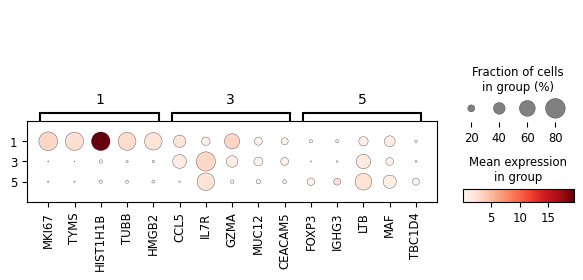

In [14]:
degs = sc_svc_analysis.get_svc_degs(focal_cluster_nums, fc_threshold=1)
marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(5).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(focal_cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

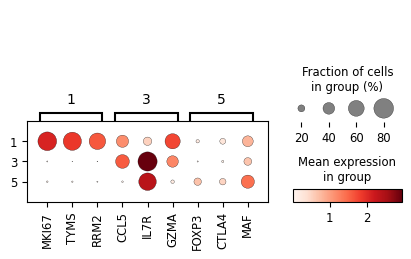

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '1': ['MKI67', 'TYMS', 'RRM2'],
    '3': ['CCL5', 'IL7R', 'GZMA'],
    '5': ['FOXP3', 'CTLA4', 'MAF']
    }

sc_svc_analysis.get_dot_plot(focal_cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## How do spatial-side and expression-side DEG results compare?

**Design.** After focal selection, two context-motivated comparisons are run independently on both objects: cluster 1 Proliferation versus cluster 3, and cluster 5 Regulation versus cluster 3. Because `spatial.h5ad` and `expr.h5ad` contain different observations and gene spaces, this is a phenotype-level head-to-head comparison, not a paired-cell test.

**How to read the outputs.** The four DEG tables retain the full ranked results. The summary criterion is `abs(logFC) > 1` and `padj < 0.01`; volcano highlighting uses the stricter display threshold `padj < 1e-6`. Local enrichment consumes the top positively changing genes from each branch.

| Phenotype | Spatial-side significant DEGs | Expression-side significant DEGs |
| --- | ---: | ---: |
| Proliferation / paper T_0 | 123 | 2287 |
| Regulation / paper T_3 | 64 | 90 |

**Direct observation.** The existing validated outputs contain more detected DEGs for Proliferation in the larger expression-side gene space (2287 versus 123; about 18.6-fold) and a smaller difference for Regulation (90 versus 64). The count difference alone is not a standalone sensitivity or superiority claim.

**Paper context.** The paper describes this panel-space/full-transcriptome comparison as raw Xenium versus sc-SVC. In this notebook, the corresponding implementation is stated more explicitly as spatial-side panel-space versus expression-side larger gene-space objects carrying the same phenotype semantics. The paper interprets the expanded transcriptomic space and marker specificity as improving resolution of T-cell functional states; that interpretation also draws on spatial patterns, marker panels, and external comparisons not rerun here.


Conducting differential expression analysis...


Conducting differential expression analysis...


Conducting differential expression analysis...
Conducting differential expression analysis...


1102

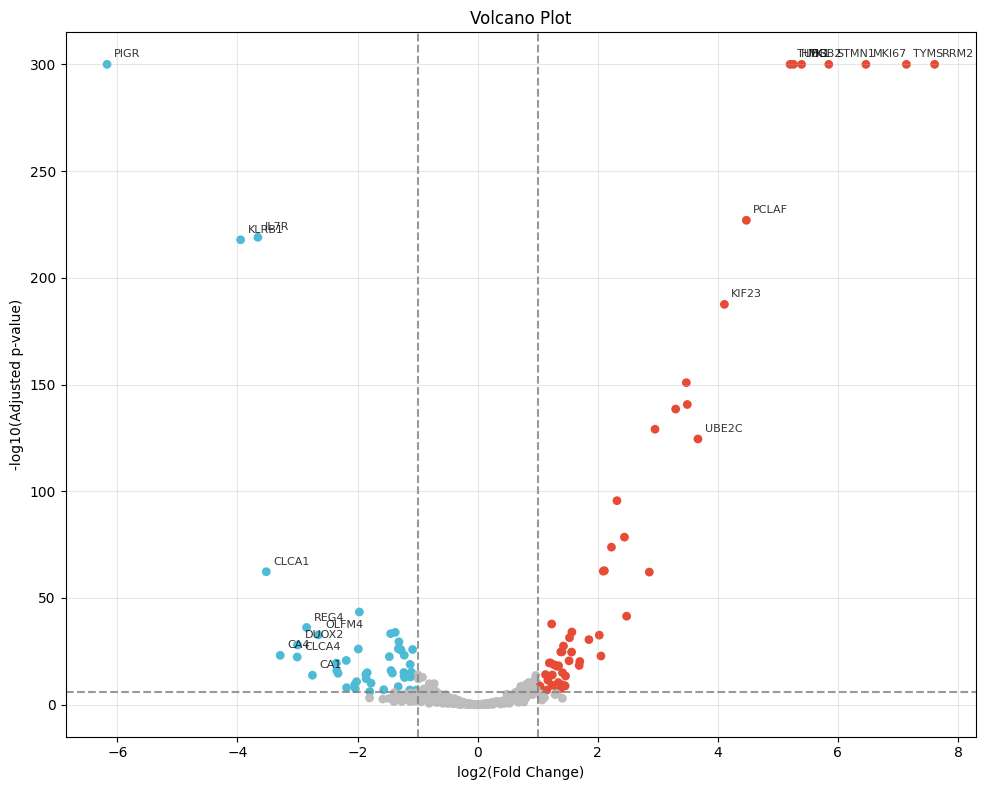

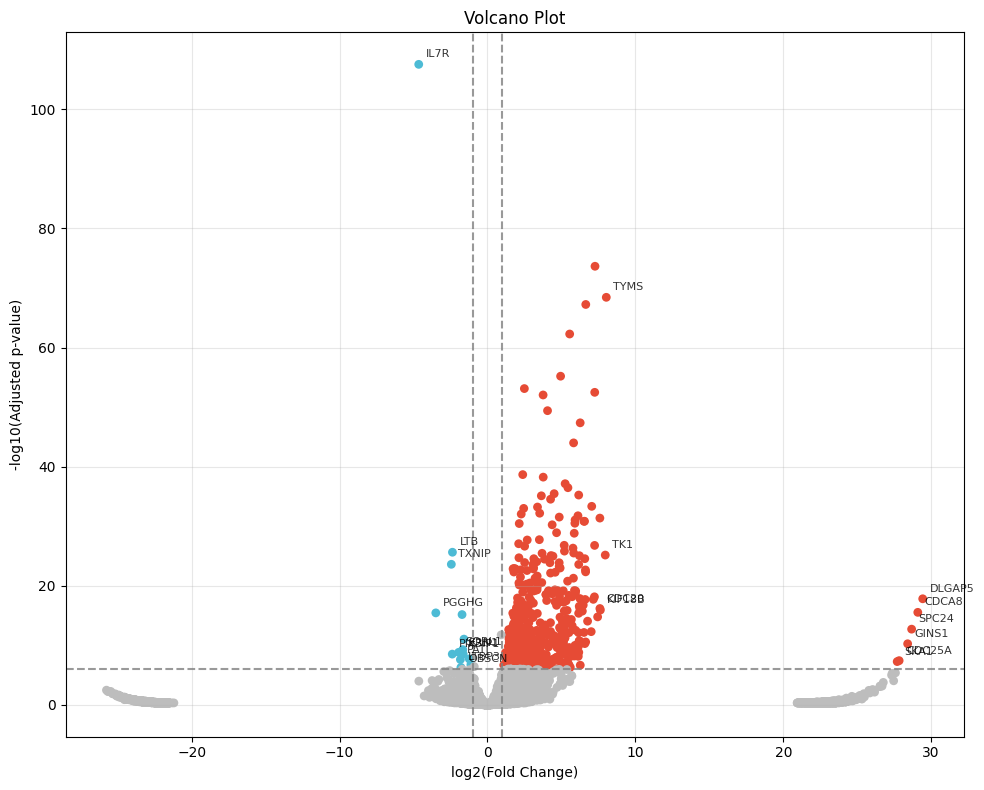

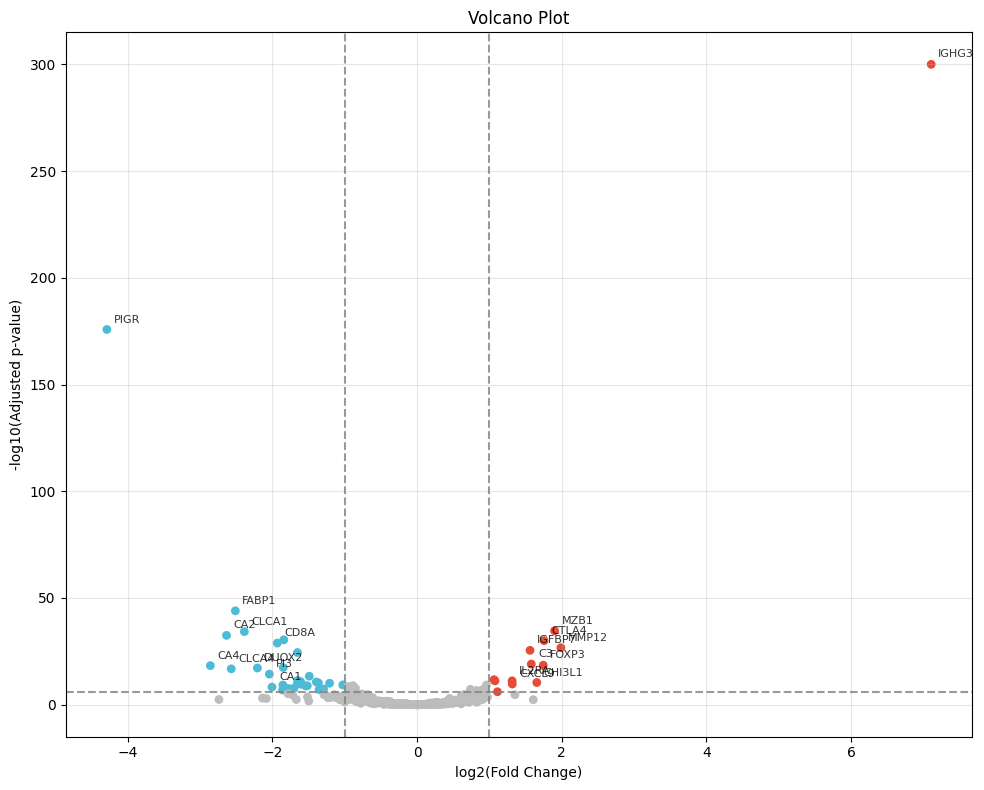

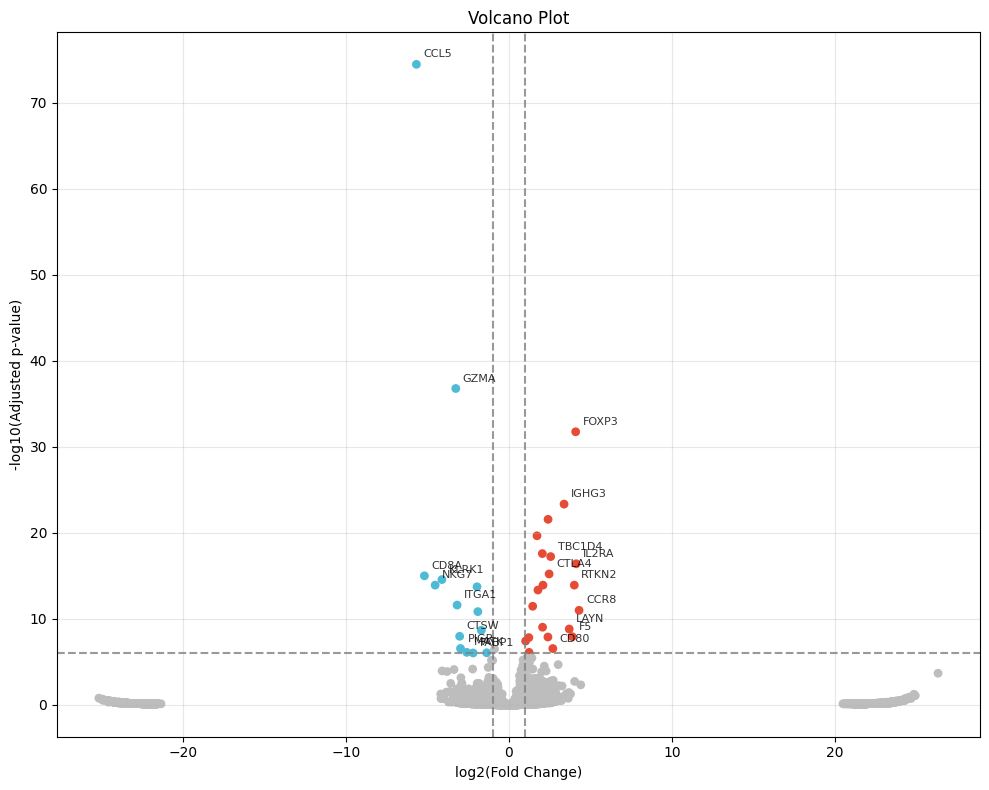

In [16]:
comparison_specs = [("1", "Proliferation"), ("5", "Regulation")]
normal_cluster = "3"
comparison_datasets = {
    "spatial": sc_svc_analysis.sc_SVC_adata_spatial.copy(),
    "expr": sc_svc_analysis.sc_SVC_adata_expr.copy(),
}

from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
from revise.analysis.bio import get_degs, get_enrichment, plot_volcano

local_resources = [{
    "id": "hallmark_gmt",
    "path": "reproduce/case/pathway/h.all.v2025.1.Hs.symbols.gmt",
    "sha256": hashlib.sha256(Path(geneset_file[0]).read_bytes()).hexdigest(),
}]
local_enrichment_runs = []
for tumor_cluster_num, phenotype in comparison_specs:
    for dataset_name in ("spatial", "expr"):
        comparison_output_dir = f"{output_dir}/comparisons/{phenotype}/{dataset_name}"
        Path(comparison_output_dir).mkdir(parents=True, exist_ok=True)
        comparison_adata = comparison_datasets[dataset_name]
        comparison_adata = comparison_adata[
            comparison_adata.obs["SVC_cluster"].astype(str).isin(
                [normal_cluster, tumor_cluster_num]
            )
        ].copy()
        comparison_adata.obs["SVC_cluster"] = (
            comparison_adata.obs["SVC_cluster"].astype(str).replace({
                normal_cluster: "Normal-infiltrated",
                tumor_cluster_num: "Tumor-infiltrated",
            })
        )
        degs = get_degs(
            comparison_adata,
            groupby="SVC_cluster",
            method="t-test",
            fc_threshold=None,
        )
        degs = degs[degs["group"] == "Tumor-infiltrated"].reset_index(drop=True)
        degs.to_csv(f"{comparison_output_dir}/degs.csv", index=False)
        plot_volcano(
            degs,
            logfc_threshold=1,
            padj_threshold=1e-6,
            top_k=10,
            save_file_name=f"{comparison_output_dir}/volcano.pdf",
        )
        started_at = datetime.now(timezone.utc).isoformat()
        pathway = get_enrichment(
            degs.loc[degs["logfoldchanges"] > 0, "gene"].head(60).tolist(),
            geneset_file,
            background=None,
        )
        pathway.to_csv(f"{comparison_output_dir}/pathway.csv", index=False)
        local_enrichment_runs.append({
            "phenotype": phenotype,
            "dataset": dataset_name,
            "started_at": started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
        })

Path(f"{output_dir}/integration-evidence.json").write_text(
    json.dumps({
        "provider": "GSEApy local enrich",
        "background": None,
        "background_policy": "GSEApy default over local GMT union",
        "resources": local_resources,
        "runs": local_enrichment_runs,
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
